<a href="https://colab.research.google.com/github/brunoss-on/scimlga2026/blob/main/resources_FiltragemTiros/filtragem_tiros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import time
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import seaborn as sns
import sys
import struct
from scipy import interpolate
import torch

In [26]:
# Set up the workspace

REPO_DIR = "/content/scimlga2026"

if not os.path.exists(REPO_DIR):
    print("Cloning the SciMLGA 2026 course repository from GitHub...")
    !git clone https://github.com/brunoss-on/scimlga2026.git {REPO_DIR}
    print("Repository successfully cloned!")
else:
    print("Repository already available. Skipping clone.")

Repository already available. Skipping clone.


In [27]:
WORK_DIR = os.path.join(REPO_DIR, "resources_FiltragemTiros")
os.chdir(WORK_DIR)
print("Current directory:", os.getcwd())
print("Current contents:", os.listdir())

Current directory: /content/scimlga2026/resources_FiltragemTiros
Current contents: ['filtragem_tiros.ipynb']


In [28]:
# Load dataset
DATA_FILE = "TirosMods1.zip"
FILE_ID = "1demUCJiQE3ybdl_xpbWTJ-Q00PyBEhnc"

DATA_DIR = os.path.join(REPO_DIR,"resources_GeracaoTiros")

if not os.path.exists(f"{DATA_DIR}/TirosMods1"):
    os.makedirs(DATA_DIR, exist_ok=True)
    !pip -q install gdown
    !gdown "https://drive.google.com/uc?id={FILE_ID}" -O "{DATA_DIR}/{DATA_FILE}"

    !unzip -q -o "{DATA_DIR}/{DATA_FILE}" -d "{DATA_DIR}"
else:
    print("Data already available.")

Data already available.


In [29]:
print("Current directory:", os.getcwd())
print("Current contents:", os.listdir())
!ls "{DATA_DIR}/TirosMods1"

Current directory: /content/scimlga2026/resources_FiltragemTiros
Current contents: ['filtragem_tiros.ipynb']
shot_100.npy  shot_191.npy  shot_281.npy  shot_371.npy	shot_461.npy
shot_101.npy  shot_192.npy  shot_282.npy  shot_372.npy	shot_462.npy
shot_102.npy  shot_193.npy  shot_283.npy  shot_373.npy	shot_463.npy
shot_103.npy  shot_194.npy  shot_284.npy  shot_374.npy	shot_464.npy
shot_104.npy  shot_195.npy  shot_285.npy  shot_375.npy	shot_465.npy
shot_105.npy  shot_196.npy  shot_286.npy  shot_376.npy	shot_466.npy
shot_106.npy  shot_197.npy  shot_287.npy  shot_377.npy	shot_467.npy
shot_107.npy  shot_198.npy  shot_288.npy  shot_378.npy	shot_468.npy
shot_108.npy  shot_199.npy  shot_289.npy  shot_379.npy	shot_469.npy
shot_109.npy  shot_19.npy   shot_28.npy   shot_37.npy	shot_46.npy
shot_10.npy   shot_1.npy    shot_290.npy  shot_380.npy	shot_470.npy
shot_110.npy  shot_200.npy  shot_291.npy  shot_381.npy	shot_471.npy
shot_111.npy  shot_201.npy  shot_292.npy  shot_382.npy	shot_472.npy
shot_112.

In [30]:
data_dir ='../resources_GeracaoTiros/TirosMods1/'
# LOADING PATHS
shot_list = [xn for xn in os.listdir(data_dir) if "shot" in xn]
shot_list.sort()
y_data=[]
for i in range(len(shot_list)):
    ent=np.load(data_dir + shot_list[i])
#    ent.shape
    y_data.append(np.transpose(ent[:,:,:],(0,2,1)))
y_data = np.concatenate(y_data, axis=0)[::16,:,:]

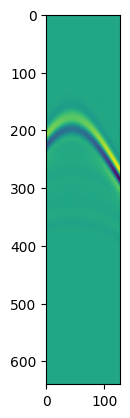

In [31]:
plt.imshow(y_data[10,:,:])

In [32]:
dt = 0.0030
dado = torch.from_numpy(y_data[100,:,:])

In [33]:
def plot_fft(dado):
    DATA = torch.sum(torch.abs(torch.fft.rfft(dado, 1024,dim=0)),dim=1)
    freq = torch.fft.rfftfreq(1024, dt)
    plt.plot(freq, DATA)
    plt.grid()
    plt.xlim(0,20)
    plt.xlabel('Freq (Hz)')
    plt.xticks(range(0, 20, 1))
    plt.title('Espectro de Amplitude ')
    plt.show()
    return

In [34]:
class BandpassFilter:
    def __init__(self, f1, f2,f3,f4, dt, N=500):

        self.f1 = f1
        self.f2 = f2
        self.f3 = f3
        self.f4 = f4
        self.dt = dt
        self.N = N

        A = (f1 + f2) * dt
        B = (f2 - f1) * dt
        C = (f3 + f4) * dt
        D = (f4 - f3) * dt

        n = torch.arange(-N, N + 1)

        self.kernel = (
            C * torch.sinc(C * n) * torch.sinc(D * n)
            - A * torch.sinc(A * n) * torch.sinc(B * n)
        )

    def __call__(self, data, axis=1):

        tam = data.shape[axis] + len(self.kernel) - 1

        data_fft = torch.fft.fft(data, n=tam, dim=axis)
        filt_fft = torch.fft.fft(self.kernel, n=tam)

        shape = [1] * data.ndim
        shape[axis] = tam

        filt_fft = filt_fft.reshape(shape)

        filtered = torch.fft.ifft(
            data_fft * filt_fft,
            n=tam,
            dim=axis
        ).real

        slc = [slice(None)] * filtered.ndim
        slc[axis] = slice(self.N, -self.N)

        return filtered[tuple(slc)]

In [35]:
bp = BandpassFilter(
    f1=4.5,
    f2=6.5,
    f3= 1/(2*dt),
    f4=1/(2*dt) ,
    dt=0.003,
    N=500
)

shot_filtered = bp(dado, axis=0)

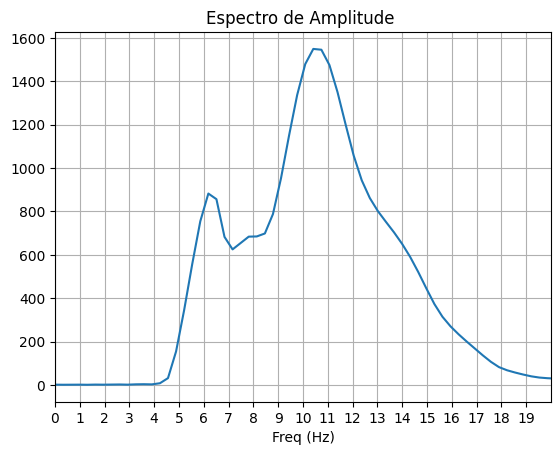

In [36]:
plot_fft(shot_filtered)

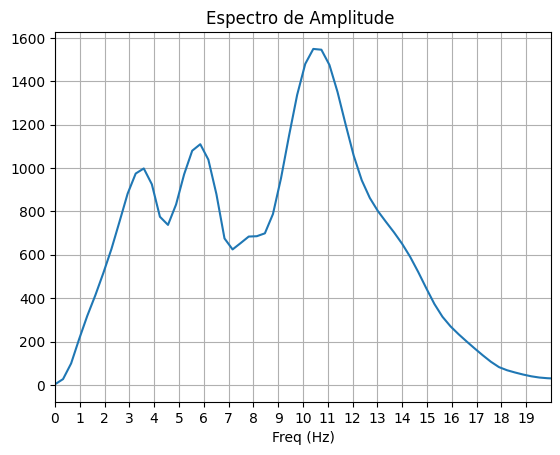

In [37]:
plot_fft(dado)

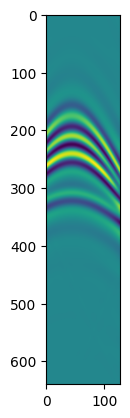

In [38]:
plt.imshow(shot_filtered)

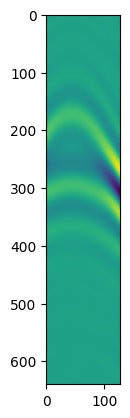

In [39]:
plt.imshow(dado-shot_filtered)

In [40]:
y_data.shape

(375, 640, 128)

In [41]:
y_data_filt=[]

for i in range(y_data.shape[0]):
    aux = bp(torch.from_numpy(y_data[i,:,:]), axis=0)
    y_data_filt.append(aux)
y_data_filt=np.array(y_data_filt)

In [42]:
np.save('input.npy',y_data_filt)
np.save('output.npy',y_data)